
TFG

Este es el codigo del tfg de Borja Jimeno

In [1]:
import sys            # módulo para interactuar con el intérprete
import os             # módulo para operaciones del sistema de archivos

import numpy as np
import math as m
import matplotlib.pyplot as plt
from scipy import special
from scipy.stats import norm

import re

sys.path.append('../../')

sys.path.append('../QF_Tamara')



from funciones_ritmo_teorico import*
from funciones_ritmo_exp import*

plt.rcParams['font.size'] = 18

In [2]:

import sys            
import os             
import numpy as np
import math as m
import matplotlib.pyplot as plt
from scipy import special
from scipy.stats import norm
import re
import numpy as np
import uproot


def carga_datos_hist(titulo,archivo):
    file = uproot.open(archivo)
    file.keys()
    longitud=36*4
    datos=np.zeros((2,longitud))
    
    graph = file[titulo]
    datos[0]=graph.member("fX")
    datos[1]=graph.member("fY")
    
    return datos


Datos_DM_16=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFtamara_DM_SG_SI","../QF_Tamara/SI_fix_1.root")
Datos_DM_16_ANOD=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFtamara_ANOD_DM_SG_SI","../QF_Tamara/SI_fix_1.root")

DM_16=Datos_DM_16[1]
DM_16_ANOD=Datos_DM_16_ANOD[1]

DM_16_m=Datos_DM_16[0]
DM_16_ANOD_m=Datos_DM_16_ANOD[0]


Datos_DM_26=carga_datos_hist("gA112_6y_90_2.000000_6.000000_QFtamara_DM_SG_SI","../QF_Tamara/SI_fix_1.root")
Datos_DM_26_ANOD=carga_datos_hist("gA112_6y_90_2.000000_6.000000_QFtamara_ANOD_DM_SG_SI","../QF_Tamara/SI_fix_1.root")

DM_26=Datos_DM_26[1]
DM_26_ANOD=Datos_DM_26_ANOD[1]

DM_26_m=Datos_DM_26[0]
DM_26_ANOD_m=Datos_DM_26_ANOD[0]

masas_ref=Datos_DM_26[0]

Datos_DM_8y_16=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFtamara_DM_SG_SI;4","../QF_Tamara/SI_8y.root")

DM_16_8y=Datos_DM_8y_16[1]

DM_16_8y_m=Datos_DM_8y_16[0]



In [3]:
def elimina_sing(array_d,array_m):
    aa=0
    while(aa==0):
        if (array_d[0]<0 or array_d[0]>1):
            array_d=np.delete(array_d,0)
            array_m=np.delete(array_m,0)
        else:
            aa=1
    return array_d,array_m

DM_16, DM_16_m = elimina_sing(DM_16,DM_16_m)

DM_16_ANOD, DM_16_ANOD_m = elimina_sing(DM_16_ANOD,DM_16_ANOD_m)

DM_26, DM_26_m = elimina_sing(DM_26,DM_26_m)

DM_26_ANOD, DM_26_ANOD_m = elimina_sing(DM_26_ANOD,DM_26_ANOD_m)

DM_16_8y, DM_16_8y_m = elimina_sing(DM_16_8y,DM_16_8y_m)



In [4]:
DAMA1=np.loadtxt("../QF_Tamara/DAMA1.txt")

DAMA1_x=[]
DAMA1_y=[]

for i in range(len(DAMA1)):
    DAMA1_x.append(DAMA1[i][0])
    DAMA1_y.append(DAMA1[i][1])

DAMA2=np.loadtxt("../QF_Tamara/DAMA2.txt")

DAMA2_x=[]
DAMA2_y=[]

for i in range(len(DAMA2)):
    DAMA2_x.append(DAMA2[i][0])
    DAMA2_y.append(DAMA2[i][1])



COSINE=np.loadtxt("../QF_Tamara/COSINE-100.txt")

COSINE_x=[]
COSINE_y=[]

for i in range(len(COSINE)):
    COSINE_x.append(COSINE[i][0])
    COSINE_y.append(COSINE[i][1])

ANAIS_SF=np.loadtxt("../QF_Tamara/SI_SF.txt")

ANAIS_SF_x=[]
ANAIS_SF_y=[]

for i in range(len(ANAIS_SF)):
    ANAIS_SF_x.append(ANAIS_SF[i][0])
    ANAIS_SF_y.append(ANAIS_SF[i][1])


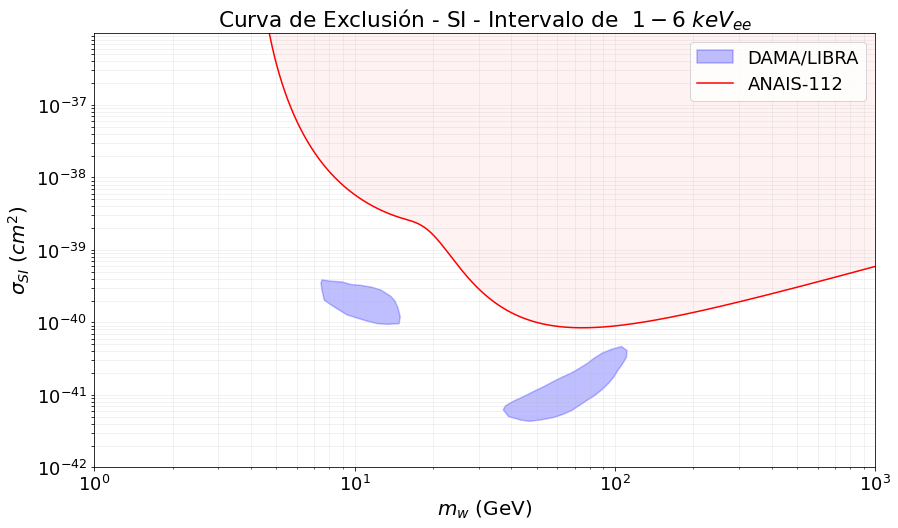

In [5]:
plt.figure(figsize=(14, 8), facecolor='white')  # Fondo blanco de la figura
ax = plt.subplot()
ax.set_facecolor('white')  # Fondo blanco del área de los ejes


ax.fill(DAMA1_x, DAMA1_y, facecolor='blue', alpha=0.25, edgecolor='blue', linewidth=1.5, label="DAMA/LIBRA")
ax.fill(DAMA2_x, DAMA2_y, facecolor='blue', alpha=0.25, edgecolor='blue', linewidth=1.5)

#ax.plot(COSINE_x,COSINE_y,c='black',linestyle="--",label="COSINE (2018)")

ax.plot(ANAIS_SF_x,ANAIS_SF_y,linestyle='-',label="ANAIS-112", alpha=1,c="red")
ax.fill_between(ANAIS_SF_x, ANAIS_SF_y, 1e-36, color='red', alpha=0.05)
#ax.plot(DM_16_m,DM_16, linestyle='-',label="1-6 $keV_{ee}$", alpha=1,c="red")
#ax.plot(DM_16_ANOD_m,DM_16_ANOD , linestyle='-', label="1-6 $keV_{ee}$ - ANOD", alpha=1,c="green")

ax.legend()

ax.set_title(r'Curva de Exclusión - SI - Intervalo de  $1-6$ $keV_{ee}$')
ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=20)
ax.set_xlabel(r'$m_w$ (GeV)',fontsize=20)

ax.set_yscale("log")
ax.set_xscale("log")

y_sup=1e-36
y_inf=1e-42

ax.set_ylim(y_inf,y_sup)
ax.set_xlim(1,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     


all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)

plt.savefig("SinFondoSI.pdf", dpi=150, facecolor='white')


In [6]:
def calcula_sigma(E_i,E_f,mW,t,cl=0.9,array_det=np.ones(9,dtype=int)):
    N_teo=numero_cuentas_teo(E_i,E_f,t,mW,1,array_det)
    N_exp=numero_cuentas_exp_CL(E_i,E_f,cl,array_det)
    return N_exp/N_teo
    


timeMax=72.9 
timeMin=255.5 
timeAvg=(timeMax+timeMin)/2.

mW_min=0.1 #masa wimp minima en GeV
mW_max=3

mWs=np.logspace(mW_min,mW_max,num=1000,endpoint=True)

#Calculamos función Numero de Cuentas teorico


sigmas16=np.zeros(len(mWs))
sigmas26=np.zeros(len(mWs))


for i in range (len(mWs)):
    sigmas16[i]=calcula_sigma(1,6,mWs[i],timeAvg)
    sigmas26[i]=calcula_sigma(2,6,mWs[i],timeAvg)
    

for i in range (len(mWs)):
    if(sigmas26[i]>1e-32):
        sigmas26[i]=1e-32

/tmp/ipykernel_74766/1765408547.py:4: RuntimeWarning: divide by zero encountered in double_scalars
  return N_exp/N_teo


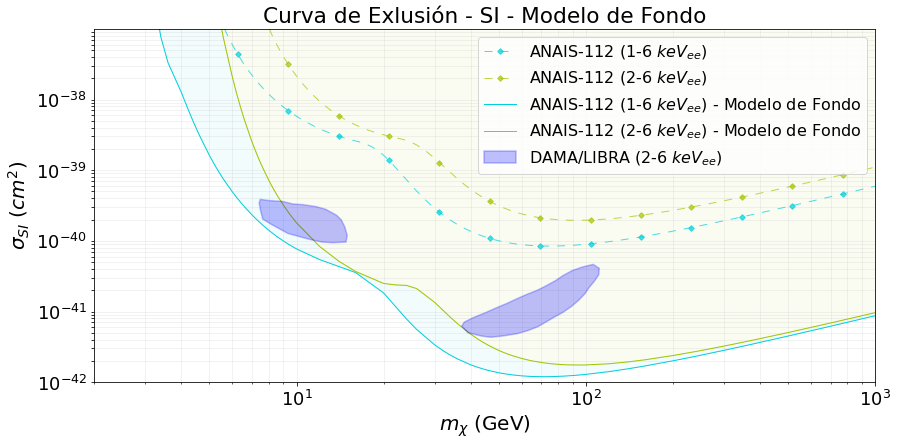

In [37]:
plt.figure(figsize=(14, 6.5), facecolor='white')  # Fondo blanco de la figura
ax = plt.subplot()
ax.set_facecolor('white')  # Fondo blanco del área de los ejes




#ax.plot(COSINE_x,COSINE_y,c='black',linestyle="--",label="COSINE (2018)")

ax.plot(mWs,sigmas16,label="ANAIS-112 (1-6 $keV_{ee}$)", linestyle=(0, (8, 8)), linewidth=1, c="#00CFDD",
        alpha=0.7,marker="D", markersize=4,markevery=60)



ax.plot(mWs,sigmas26,label="ANAIS-112 (2-6 $keV_{ee}$)", linestyle=(0, (8, 8)), linewidth=1, c="#A2C600",
        alpha=0.7,marker="D", markersize=4,markevery=60)



ax.plot(DM_16_m,DM_16, linestyle='-', linewidth=1, c="#00CFDD",
        
        label="ANAIS-112 (1-6 $keV_{ee}$) - Modelo de Fondo")

ax.plot(DM_26_m,DM_26,linestyle='-', linewidth=1, c="#A2C600",
         
         label="ANAIS-112 (2-6 $keV_{ee}$) - Modelo de Fondo")

DM_26_interp = np.interp(DM_16_m, DM_26_m, DM_26)
ax.fill_between(DM_16_m, DM_16, DM_26_interp, color="#00CFDD", alpha=0.05)

ax.fill_between(DM_26_m, DM_26, 1e-36, color="#A2C600", alpha=0.05)
#ax.plot(DM_16_ANOD_m,DM_16_ANOD , linestyle='-', label="1-6 $keV_{ee}$ - ANOD", alpha=1,c="green")
ax.fill(DAMA1_x, DAMA1_y, facecolor='blue',zorder=10, alpha=0.25, edgecolor='blue', linewidth=1.5, label="DAMA/LIBRA (2-6 $keV_{ee}$)")
ax.fill(DAMA2_x, DAMA2_y, facecolor='blue',zorder=10, alpha=0.25, edgecolor='blue', linewidth=1.5)

ax.legend(fontsize=16)

ax.set_title(r'Curva de Exlusión - SI - Modelo de Fondo')
ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=20)
ax.set_xlabel(r'$m_\chi$ (GeV)',fontsize=20)

ax.set_yscale("log")
ax.set_xscale("log")

y_sup=1e-37
y_inf=1e-42

ax.set_ylim(y_inf,y_sup)
ax.set_xlim(2,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     


all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)

plt.savefig("ConFondo_SI.pdf", dpi=150, facecolor='white',bbox_inches='tight')
